# WavLM on Annotated VocalSet

Ноутбук делает:
1. Загрузка и подготовка метаданных из `Annotated VocalSet`.
2. Базовый EDA (основные распределения).
3. Fine-tuning `microsoft/wavlm-base` для классификации техник (`Technique`).
4. Подсчет метрик на validation и сохранение артефактов.

## Источник данных
- Аннотации: `datasets/Annotated VocalSet/extended 4/all files.csv`
- Пути к аудио: `data/eda_cache/vocalset_audio_v3.csv`


In [19]:
# Optional install (раскомментируй при необходимости)
# !pip install -U "transformers[torch]" datasets accelerate evaluate librosa soundfile torchaudio scikit-learn seaborn

import inspect
import json
import random
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import soundfile as sf
import comet_ml
import torch
import torchaudio
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GroupShuffleSplit, train_test_split

from transformers import (
    AutoFeatureExtractor,
    AutoModelForAudioClassification,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)

print('torch:', torch.__version__)


torch: 2.11.0+cu130


In [20]:
# Config
SEED = 42
VAL_SIZE = 0.1

MODEL_CHECKPOINT = 'microsoft/wavlm-base'
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
MIN_LEARNING_RATE = 5e-6
TRAIN_BATCH_SIZE = 4
EVAL_BATCH_SIZE = 4
GRAD_ACCUM_STEPS = 4
MAX_AUDIO_SEC = 14.0
FREEZE_FEATURE_ENCODER = True
FREEZE_BACKBONE = False
EVAL_STEPS = 20
RUN_NAME = 'wavlm_annotated_full_tuning'

ANNOTATED_EXTENDED_VERSION = 4
MIN_CLASS_SAMPLES = 30  # классы с меньшим числом файлов будут отброшены

# Пример: ALLOWED_MUSIC_TYPES = ['Arpeggio', 'Scale', 'Long_tones']
ALLOWED_MUSIC_TYPES = None

MAX_TRAIN_SAMPLES = None  # например 2000 для быстрого запуска
MAX_VAL_SAMPLES = None


def cuda_backend_ok() -> bool:
    if not torch.cuda.is_available():
        return False
    try:
        x = torch.tensor([0.0], device='cuda')
        y = x + 1.0
        _ = float(y.item())
        torch.cuda.synchronize()
        return True
    except Exception as e:
        print(f'CUDA disabled due to runtime incompatibility: {e}')
        return False


USE_CUDA = cuda_backend_ok()
DEVICE = 'cuda' if USE_CUDA else 'cpu'
print('Training device:', DEVICE)

OUTPUT_DIR_REL = Path('MainExperiments/outputs/wavlm_annotated_vocalset')


def slugify_run_name(name: str) -> str:
    s = ''.join(ch.lower() if ch.isalnum() else '_' for ch in str(name))
    while '__' in s:
        s = s.replace('__', '_')
    s = s.strip('_')
    return s or 'run'


def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(SEED)


Training device: cuda


In [21]:
# Locate files and load raw metadata
ANNOTATED_CSV_REL = Path(f'datasets/Annotated VocalSet/extended {ANNOTATED_EXTENDED_VERSION}/all files.csv')
VOCALSET_INV_REL = Path('data/eda_cache/vocalset_audio_v3.csv')


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / ANNOTATED_CSV_REL).exists() and (p / VOCALSET_INV_REL).exists():
            return p
    raise FileNotFoundError('Could not locate project root with Annotated VocalSet and vocalset inventory files')


PROJECT_ROOT = find_project_root()
ANNOTATED_CSV = PROJECT_ROOT / ANNOTATED_CSV_REL
VOCALSET_INV_CSV = PROJECT_ROOT / VOCALSET_INV_REL
OUTPUT_ROOT = PROJECT_ROOT / OUTPUT_DIR_REL
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)


def get_output_dir_for_run(run_name: str) -> Path:
    run_dir = OUTPUT_ROOT / slugify_run_name(run_name)
    run_dir.mkdir(parents=True, exist_ok=True)
    return run_dir


OUTPUT_DIR = get_output_dir_for_run(RUN_NAME)
print('RUN_NAME =', RUN_NAME)
print('OUTPUT_DIR =', OUTPUT_DIR)

print('PROJECT_ROOT =', PROJECT_ROOT)
print('ANNOTATED_CSV =', ANNOTATED_CSV)
print('VOCALSET_INV_CSV =', VOCALSET_INV_CSV)

# Trailing comma in CSV can shift parsing; use explicit usecols/index_col=False.
ann_raw = pd.read_csv(
    ANNOTATED_CSV,
    index_col=False,
    usecols=list(range(36)),
    skipinitialspace=True,
)
inv_raw = pd.read_csv(VOCALSET_INV_CSV)

print('ann_raw shape:', ann_raw.shape)
print('inv_raw shape:', inv_raw.shape)


RUN_NAME = wavlm_annotated_full_tuning
OUTPUT_DIR = /home/evgeniy/Projects/VocalAssistant/MainExperiments/outputs/wavlm_annotated_vocalset/wavlm_annotated_full_tuning
PROJECT_ROOT = /home/evgeniy/Projects/VocalAssistant
ANNOTATED_CSV = /home/evgeniy/Projects/VocalAssistant/datasets/Annotated VocalSet/extended 4/all files.csv
VOCALSET_INV_CSV = /home/evgeniy/Projects/VocalAssistant/data/eda_cache/vocalset_audio_v3.csv
ann_raw shape: (36535, 36)
inv_raw shape: (3613, 16)


In [22]:
# Build one-row-per-audio metadata from Annotated VocalSet and attach audio paths
BASE_COLS = ['File Name', 'Gender', 'Singer Name', 'Technique', 'Music Type', 'Vowel', 'Total Duration']


def normalize_text(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    return s if s else np.nan


def first_non_empty(series: pd.Series):
    s = series.dropna()
    if len(s) == 0:
        return np.nan
    s = s.astype(str).str.strip()
    s = s[s != '']
    if len(s) == 0:
        return np.nan
    return s.iloc[0]


ann = ann_raw[BASE_COLS].copy()
for col in BASE_COLS:
    ann[col] = ann[col].map(normalize_text)

ann = ann.dropna(subset=['File Name']).copy()
ann = ann.rename(columns={'File Name': 'stem'})

# one sample per audio stem
ann_meta = (
    ann.groupby('stem', as_index=False)
       .agg({
           'Gender': first_non_empty,
           'Singer Name': first_non_empty,
           'Technique': first_non_empty,
           'Music Type': first_non_empty,
           'Vowel': first_non_empty,
           'Total Duration': 'max',
       })
)

ann_meta = ann_meta.dropna(subset=['Technique', 'Singer Name']).copy()

# optional filter by music type
if ALLOWED_MUSIC_TYPES is not None:
    allowed = set([str(x).strip() for x in ALLOWED_MUSIC_TYPES])
    ann_meta = ann_meta[ann_meta['Music Type'].isin(allowed)].copy()

# attach audio path from vocalset inventory
inv = inv_raw[['stem', 'path', 'duration_sec', 'singer', 'gender']].copy()
meta = ann_meta.merge(inv, on='stem', how='left')

# absolute paths + exists check
meta['path'] = meta['path'].astype(str)
meta['path'] = meta['path'].map(lambda p: str((PROJECT_ROOT / p).resolve()) if p != 'nan' else p)
path_exists = meta['path'].map(lambda p: Path(p).exists() if p != 'nan' else False)
missing_paths = int((~path_exists).sum())
if missing_paths > 0:
    print(f'Dropped {missing_paths} rows without existing audio path')
meta = meta[path_exists].reset_index(drop=True)

# class filtering by min count
label_counts = meta['Technique'].value_counts()
keep_labels = label_counts[label_counts >= MIN_CLASS_SAMPLES].index
meta = meta[meta['Technique'].isin(keep_labels)].copy()

meta = meta.rename(columns={
    'Technique': 'label',
    'Singer Name': 'group_id',
    'Gender': 'gender_ann',
    'Music Type': 'music_type_ann',
    'Vowel': 'vowel_ann',
})

print('Prepared dataset shape:', meta.shape)
print('Num labels:', meta['label'].nunique())
print('Label counts:')
print(meta['label'].value_counts().to_string())

meta.to_csv(OUTPUT_DIR / 'prepared_metadata.csv', index=False)
print('Saved prepared metadata ->', OUTPUT_DIR / 'prepared_metadata.csv')


Dropped 5 rows without existing audio path
Prepared dataset shape: (2664, 11)
Num labels: 16
Label counts:
label
Slow_Legato_Piano         393
Fast_Articulated_Piano    358
Fast_Articulated_Forte    338
StraightTone              250
Belt_Harsh                190
Lip_Trill                 159
MoltoVibrato              139
Slow_Legato_Forte         101
MessaDiVoce                99
Slow_StraightTone          95
FullVoice                  95
Trillo                     93
Trill                      90
Slow_MoltoVibrato          89
VeryBreathy                88
Breathy                    87
Saved prepared metadata -> /home/evgeniy/Projects/VocalAssistant/MainExperiments/outputs/wavlm_annotated_vocalset/wavlm_annotated_full_tuning/prepared_metadata.csv


/tmp/ipykernel_89662/1137963778.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lbl.index, y=lbl.values, ax=axes[0, 0], palette='viridis')
/tmp/ipykernel_89662/1137963778.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=g.index, y=g.values, ax=axes[0, 1], palette='mako')
/tmp/ipykernel_89662/1137963778.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mt.index, y=mt.values, ax=axes[1, 0], palette='crest')


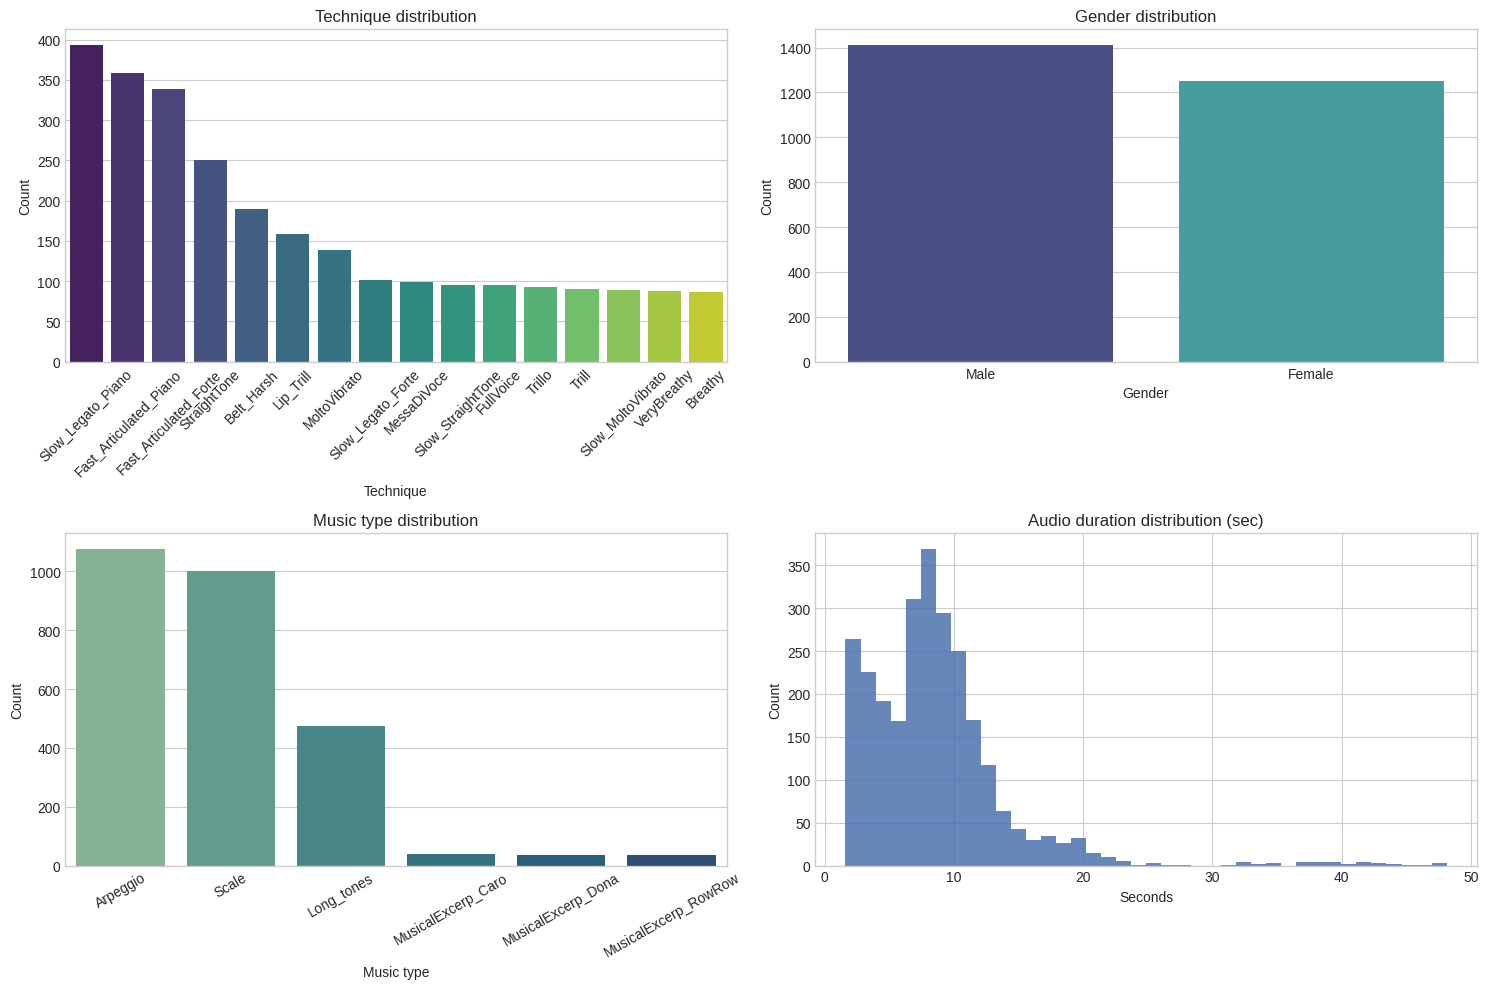

Speaker x Label crosstab (head):
label     Belt_Harsh  Breathy  Fast_Articulated_Forte  Fast_Articulated_Piano  FullVoice  Lip_Trill  MessaDiVoce  MoltoVibrato  Slow_Legato_Forte  Slow_Legato_Piano  Slow_MoltoVibrato  Slow_StraightTone  StraightTone  Trill  Trillo  VeryBreathy
group_id                                                                                                                                                                                                                                            
f1                10        5                      20                      20          5          5            5             8                  8                 20                  5                  5            13      5       5            5
f2                10        5                      20                      20          5          5            5             8                  6                 20                  5                  5            13      5       5 

In [23]:
# Basic EDA (main distributions)
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1) label distribution
lbl = meta['label'].value_counts()
sns.barplot(x=lbl.index, y=lbl.values, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Technique distribution')
axes[0, 0].set_xlabel('Technique')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2) gender distribution
if 'gender_ann' in meta.columns:
    g = meta['gender_ann'].fillna('unknown').astype(str).value_counts()
    sns.barplot(x=g.index, y=g.values, ax=axes[0, 1], palette='mako')
    axes[0, 1].set_title('Gender distribution')
    axes[0, 1].set_xlabel('Gender')
    axes[0, 1].set_ylabel('Count')
else:
    axes[0, 1].text(0.5, 0.5, 'No gender column', ha='center', va='center')
    axes[0, 1].set_axis_off()

# 3) music type distribution
if 'music_type_ann' in meta.columns:
    mt = meta['music_type_ann'].fillna('unknown').astype(str).value_counts()
    sns.barplot(x=mt.index, y=mt.values, ax=axes[1, 0], palette='crest')
    axes[1, 0].set_title('Music type distribution')
    axes[1, 0].set_xlabel('Music type')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].tick_params(axis='x', rotation=30)
else:
    axes[1, 0].text(0.5, 0.5, 'No music type column', ha='center', va='center')
    axes[1, 0].set_axis_off()

# 4) duration distribution
dur_col = 'duration_sec' if 'duration_sec' in meta.columns else None
if dur_col is not None:
    axes[1, 1].hist(meta[dur_col].dropna(), bins=40, color='#4C72B0', alpha=0.85)
    axes[1, 1].set_title('Audio duration distribution (sec)')
    axes[1, 1].set_xlabel('Seconds')
    axes[1, 1].set_ylabel('Count')
else:
    axes[1, 1].text(0.5, 0.5, 'No duration column', ha='center', va='center')
    axes[1, 1].set_axis_off()

plt.tight_layout()
plt.show()

print('Speaker x Label crosstab (head):')
ct = pd.crosstab(meta['group_id'], meta['label'])
print(ct.head(20).to_string())


In [24]:
# Train/validation split

def maybe_subsample(df_in: pd.DataFrame, max_n: int | None, seed: int = 42) -> pd.DataFrame:
    if max_n is None or len(df_in) <= max_n:
        return df_in.reset_index(drop=True)
    return df_in.sample(n=max_n, random_state=seed).reset_index(drop=True)


labels_all = set(meta['label'].unique())
splitter = GroupShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=SEED)
train_idx, val_idx = next(splitter.split(meta, y=meta['label'], groups=meta['group_id']))

train_df = meta.iloc[train_idx].reset_index(drop=True)
val_df = meta.iloc[val_idx].reset_index(drop=True)

# fallback to stratified split if grouped split drops labels
if set(train_df['label'].unique()) != labels_all or set(val_df['label'].unique()) != labels_all:
    print('Grouped split missed at least one class -> fallback to stratified split.')
    train_df, val_df = train_test_split(
        meta,
        test_size=VAL_SIZE,
        random_state=SEED,
        stratify=meta['label'],
    )
    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)

train_df = maybe_subsample(train_df, MAX_TRAIN_SAMPLES, seed=SEED)
val_df = maybe_subsample(val_df, MAX_VAL_SAMPLES, seed=SEED)

labels_sorted = sorted(train_df['label'].unique())
label2id = {lbl: i for i, lbl in enumerate(labels_sorted)}
id2label = {i: lbl for lbl, i in label2id.items()}

train_df['label_id'] = train_df['label'].map(label2id).astype(int)
val_df['label_id'] = val_df['label'].map(label2id).astype(int)

print('train size:', len(train_df), '| val size:', len(val_df))
print('train labels:')
print(train_df['label'].value_counts().to_string())
print('\nval labels:')
print(val_df['label'].value_counts().to_string())
print('\nlabel2id:', label2id)


train size: 2386 | val size: 278
train labels:
label
Slow_Legato_Piano         353
Fast_Articulated_Piano    318
Fast_Articulated_Forte    298
StraightTone              225
Belt_Harsh                170
Lip_Trill                 145
MoltoVibrato              123
MessaDiVoce                89
Slow_Legato_Forte          88
Slow_StraightTone          85
FullVoice                  85
VeryBreathy                83
Trillo                     83
Breathy                    82
Trill                      80
Slow_MoltoVibrato          79

val labels:
label
Fast_Articulated_Piano    40
Fast_Articulated_Forte    40
Slow_Legato_Piano         40
StraightTone              25
Belt_Harsh                20
MoltoVibrato              16
Lip_Trill                 14
Slow_Legato_Forte         13
MessaDiVoce               10
Slow_StraightTone         10
Slow_MoltoVibrato         10
FullVoice                 10
Trillo                    10
Trill                     10
VeryBreathy                5
Breathy      

In [25]:
# Build HF datasets + collator + metrics
feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL_CHECKPOINT)
sampling_rate = int(getattr(feature_extractor, 'sampling_rate', 16000) or 16000)
max_length = int(MAX_AUDIO_SEC * sampling_rate)


def to_hf_dataset(df_in: pd.DataFrame) -> Dataset:
    ds = Dataset.from_pandas(df_in[['path', 'label_id']], preserve_index=False)
    ds = ds.rename_column('path', 'audio_path')
    return ds


train_ds = to_hf_dataset(train_df)
val_ds = to_hf_dataset(val_df)


@dataclass
class AudioCollator:
    feature_extractor: AutoFeatureExtractor
    max_length: int
    target_sampling_rate: int

    def _load_waveform(self, path: str) -> np.ndarray:
        # Use soundfile to avoid torchcodec backend issues in torchaudio.load
        waveform, sr = sf.read(path, dtype='float32', always_2d=False)

        if waveform.ndim == 2:
            # soundfile shape is [time, channels]
            waveform = waveform.mean(axis=1)

        wav_t = torch.from_numpy(np.asarray(waveform, dtype=np.float32))
        if sr != self.target_sampling_rate:
            wav_t = torchaudio.functional.resample(wav_t, sr, self.target_sampling_rate)

        return wav_t.numpy().astype(np.float32)

    def __call__(self, features):
        arrays = [self._load_waveform(f['audio_path']) for f in features]

        batch = self.feature_extractor(
            arrays,
            sampling_rate=self.target_sampling_rate,
            truncation=True,
            max_length=self.max_length,
            padding=True,
            return_tensors='pt',
        )
        batch['labels'] = torch.tensor([int(f['label_id']) for f in features], dtype=torch.long)
        return batch


compute_label_ids = list(range(len(label2id)))


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, labels=compute_label_ids, average='macro', zero_division=0),
        'precision_macro': precision_score(labels, preds, labels=compute_label_ids, average='macro', zero_division=0),
        'recall_macro': recall_score(labels, preds, labels=compute_label_ids, average='macro', zero_division=0),
    }


In [26]:
# Model + Trainer
model = AutoModelForAudioClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=len(label2id),
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,
    problem_type='single_label_classification',
)

if FREEZE_FEATURE_ENCODER and hasattr(model, 'freeze_feature_encoder'):
    model.freeze_feature_encoder()
if FREEZE_BACKBONE:
    model.requires_grad_(False)
    for params in [model.projector.parameters(), model.classifier.parameters()]:
        for p in params:
            p.requires_grad = True


def build_training_args(output_dir: Path) -> TrainingArguments:
    ta_params = set(inspect.signature(TrainingArguments.__init__).parameters.keys())

    kwargs = {
        'output_dir': str(output_dir),
        'learning_rate': LEARNING_RATE,
        'per_device_train_batch_size': TRAIN_BATCH_SIZE,
        'per_device_eval_batch_size': EVAL_BATCH_SIZE,
        'gradient_accumulation_steps': GRAD_ACCUM_STEPS,
        'num_train_epochs': NUM_EPOCHS,
        'warmup_ratio': 0.1,
        'weight_decay': 0.01,
        'save_total_limit': 2,
        'load_best_model_at_end': True,
        'lr_scheduler_type': 'cosine_with_min_lr',
        'lr_scheduler_kwargs': {
            'min_lr': MIN_LEARNING_RATE,
        },
        'metric_for_best_model': 'f1_macro',
        'greater_is_better': True,
        'seed': SEED,
        'remove_unused_columns': False,
        'report_to': 'comet_ml',
        'run_name': RUN_NAME,
        'dataloader_num_workers': 2,
    }

    if USE_CUDA and 'fp16' in ta_params:
        kwargs['fp16'] = True

    if not USE_CUDA and 'no_cuda' in ta_params:
        kwargs['no_cuda'] = True
    if not USE_CUDA and 'use_cpu' in ta_params:
        kwargs['use_cpu'] = True

    if 'evaluation_strategy' in ta_params:
        kwargs['evaluation_strategy'] = 'steps'
    elif 'eval_strategy' in ta_params:
        kwargs['eval_strategy'] = 'steps'

    if 'save_strategy' in ta_params:
        kwargs['save_strategy'] = 'steps'
    if 'logging_strategy' in ta_params:
        kwargs['logging_strategy'] = 'steps'
    if 'logging_steps' in ta_params:
        kwargs['logging_steps'] = 20

    kwargs = {k: v for k, v in kwargs.items() if k in ta_params}
    return TrainingArguments(**kwargs)


Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

WavLMForSequenceClassification LOAD REPORT from: microsoft/wavlm-base
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
projector.bias    | MISSING | 
classifier.bias   | MISSING | 
projector.weight  | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [27]:
from torchinfo import summary

summary(model, col_names=["num_params", "trainable"])


Layer (type:depth-idx)                                  Param #                   Trainable
WavLMForSequenceClassification                          --                        Partial
├─WavLMModel: 1-1                                       768                       Partial
│    └─WavLMFeatureEncoder: 2-1                         --                        False
│    │    └─ModuleList: 3-1                             (4,200,448)               False
│    └─WavLMFeatureProjection: 2-2                      --                        True
│    │    └─LayerNorm: 3-2                              1,024                     True
│    │    └─Linear: 3-3                                 393,984                   True
│    │    └─Dropout: 3-4                                --                        --
│    └─WavLMEncoder: 2-3                                --                        True
│    │    └─WavLMPositionalConvEmbedding: 3-5           4,719,488                 True
│    │    └─LayerNorm: 3-6      

In [28]:
# LR range test (before full training)
import os
import tempfile


def _move_batch_to_device(batch, device):
    out = {}
    for k, v in batch.items():
        if torch.is_tensor(v):
            out[k] = v.to(device, non_blocking=True)
        else:
            out[k] = v
    return out


def run_lr_range_test(
    model,
    train_dataloader,
    device,
    start_lr=1e-7,
    end_lr=1.0,
    num_iter=80,
    beta=0.98,
    stop_factor=4.0,
    max_grad_norm=1.0,
):
    if num_iter < 2:
        raise ValueError('num_iter must be >= 2')

    with tempfile.NamedTemporaryFile(delete=False, suffix='.pt') as tmp:
        backup_path = tmp.name
    torch.save(model.state_dict(), backup_path)

    optimizer = torch.optim.AdamW(model.parameters(), lr=start_lr)
    lr_mult = (end_lr / start_lr) ** (1.0 / (num_iter - 1))

    lrs, losses, smooth_losses = [], [], []
    avg_loss = 0.0
    best_loss = float('inf')

    model.train()
    iterator = iter(train_dataloader)

    try:
        for it in range(num_iter):
            try:
                batch = next(iterator)
            except StopIteration:
                iterator = iter(train_dataloader)
                batch = next(iterator)

            current_lr = start_lr * (lr_mult ** it)
            for pg in optimizer.param_groups:
                pg['lr'] = current_lr

            batch = _move_batch_to_device(batch, device)
            optimizer.zero_grad(set_to_none=True)
            outputs = model(**batch)
            loss = outputs.loss
            loss.backward()

            if max_grad_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

            optimizer.step()

            loss_item = float(loss.detach().item())
            avg_loss = beta * avg_loss + (1.0 - beta) * loss_item
            smooth_loss = avg_loss / (1.0 - beta ** (it + 1))

            lrs.append(current_lr)
            losses.append(loss_item)
            smooth_losses.append(smooth_loss)

            if smooth_loss < best_loss:
                best_loss = smooth_loss

            if it > 10 and (not np.isfinite(smooth_loss) or smooth_loss > stop_factor * best_loss):
                print(f'Stopping early at iter={it} due to divergence.')
                break

    finally:
        state = torch.load(backup_path, map_location='cpu')
        model.load_state_dict(state)
        model.to(device)
        model.zero_grad(set_to_none=True)
        try:
            os.remove(backup_path)
        except OSError:
            pass

    return {
        'lrs': np.array(lrs, dtype=np.float64),
        'losses': np.array(losses, dtype=np.float64),
        'smooth_losses': np.array(smooth_losses, dtype=np.float64),
    }


In [29]:
# Evaluate + save artifacts (train + validation)

def build_split_artifacts(pred_out, id2label):
    y_true = pred_out.label_ids
    y_pred = np.argmax(pred_out.predictions, axis=-1)

    ordered_ids = list(sorted(id2label.keys()))
    ordered_labels = [id2label[i] for i in ordered_ids]

    report = classification_report(
        y_true,
        y_pred,
        labels=ordered_ids,
        target_names=ordered_labels,
        output_dict=True,
        zero_division=0,
    )
    report_df = pd.DataFrame(report).T

    cm = confusion_matrix(y_true, y_pred, labels=ordered_ids)
    cm_df = pd.DataFrame(cm, index=ordered_labels, columns=ordered_labels)

    metrics = {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'f1_macro': float(f1_score(y_true, y_pred, labels=ordered_ids, average='macro', zero_division=0)),
        'precision_macro': float(precision_score(y_true, y_pred, labels=ordered_ids, average='macro', zero_division=0)),
        'recall_macro': float(recall_score(y_true, y_pred, labels=ordered_ids, average='macro', zero_division=0)),
    }

    return metrics, report_df, cm_df


def safe_trainer_evaluate(trainer, eval_dataset):
    try:
        return trainer.evaluate(eval_dataset=eval_dataset)
    except RuntimeError as e:
        msg = str(e)
        if 'on_train_begin must be called before on_evaluate' in msg:
            print('NotebookProgressCallback issue detected; skipping trainer.evaluate and using predict-based metrics.')
            return {'eval_skipped_due_to_callback_issue': True}
        raise

def _checkpoint_step(path: Path) -> int:
    name = path.name
    if name.startswith('checkpoint-'):
        tail = name.split('checkpoint-')[-1]
        if tail.isdigit():
            return int(tail)
    return -1


def list_checkpoints(output_dir: Path) -> list[Path]:
    output_dir = Path(output_dir)
    checkpoints = [p for p in output_dir.glob('checkpoint-*') if p.is_dir()]
    checkpoints.sort(key=lambda p: _checkpoint_step(p))
    return checkpoints


def resolve_checkpoint_path(output_dir: Path, checkpoint: str | Path | None = 'latest') -> Path | None:
    if checkpoint is None or checkpoint is False:
        return None

    output_dir = Path(output_dir)

    if checkpoint == 'latest':
        checkpoints = list_checkpoints(output_dir)
        return checkpoints[-1] if checkpoints else None

    ckpt = Path(checkpoint)
    if not ckpt.is_absolute():
        # allow both 'checkpoint-3000' and 'some/other/path'
        if ckpt.parts and ckpt.parts[0].startswith('checkpoint-'):
            ckpt = output_dir / ckpt
        else:
            ckpt = (Path.cwd() / ckpt).resolve()

    return ckpt


def load_checkpoint_into_trainer_for_eval(
    trainer,
    output_dir: Path,
    checkpoint: str | Path | None = 'latest',
):
    ckpt = resolve_checkpoint_path(output_dir=output_dir, checkpoint=checkpoint)
    if ckpt is None:
        print('No checkpoint selected for evaluation. Using current in-memory model.')
        return None

    ckpt = Path(ckpt)
    if not ckpt.exists():
        raise FileNotFoundError(f'Checkpoint not found: {ckpt}')

    if not hasattr(trainer, '_load_from_checkpoint'):
        raise RuntimeError('Trainer has no _load_from_checkpoint method in this transformers version')

    trainer._load_from_checkpoint(str(ckpt))
    trainer.model.to(trainer.args.device)
    trainer.model.eval()
    print(f'Loaded checkpoint for evaluation: {ckpt}')
    return ckpt


In [30]:
# t-SNE utilities for validation embeddings + classifier references
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D


def _unwrap_audio_cls_model(model):
    m = model.module if hasattr(model, 'module') else model
    if hasattr(m, 'base_model') and hasattr(m.base_model, 'model'):
        base = m.base_model.model
    else:
        base = m
    return m, base


def _get_classifier_weight_matrix(base_model):
    classifier = getattr(base_model, 'classifier', None)
    if classifier is None:
        raise AttributeError('Model has no classifier attribute')

    if hasattr(classifier, 'weight') and classifier.weight is not None:
        return classifier.weight.detach().float().cpu().numpy()

    if hasattr(classifier, 'modules_to_save'):
        mts = classifier.modules_to_save
        if isinstance(mts, dict) and len(mts) > 0:
            module = next(iter(mts.values()))
            if hasattr(module, 'weight') and module.weight is not None:
                return module.weight.detach().float().cpu().numpy()

    if hasattr(classifier, 'original_module') and hasattr(classifier.original_module, 'weight'):
        return classifier.original_module.weight.detach().float().cpu().numpy()

    for _, param in classifier.named_parameters():
        if param.ndim == 2:
            return param.detach().float().cpu().numpy()

    raise RuntimeError('Could not find classifier weight matrix for reference vectors')


def _masked_mean_pool(hidden_states, attention_mask, base_model):
    if attention_mask is None or not hasattr(base_model, '_get_feature_vector_attention_mask'):
        return hidden_states.mean(dim=1)

    feat_mask = base_model._get_feature_vector_attention_mask(hidden_states.shape[1], attention_mask)
    feat_mask = feat_mask.to(hidden_states.device)
    hidden_states = hidden_states * feat_mask.unsqueeze(-1)
    denom = feat_mask.sum(dim=1).unsqueeze(-1).clamp(min=1)
    return hidden_states.sum(dim=1) / denom


def extract_embeddings_and_references(model, dataloader, processor, device):
    _ = processor  # kept in signature for compatibility with notebook pipeline

    wrapper_model, base_model = _unwrap_audio_cls_model(model)
    target_device = torch.device(device)

    if hasattr(base_model, 'wav2vec2'):
        backbone = base_model.wav2vec2
    elif hasattr(base_model, 'wavlm'):
        backbone = base_model.wavlm
    elif hasattr(base_model, 'hubert'):
        backbone = base_model.hubert
    else:
        raise AttributeError('Backbone not found (expected wav2vec2/wavlm/hubert)')

    was_training = wrapper_model.training
    wrapper_model.eval()

    embeddings = []
    labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_values = batch['input_values'].to(target_device)
            attention_mask = batch.get('attention_mask')
            if attention_mask is not None:
                attention_mask = attention_mask.to(target_device)

            outputs = backbone(
                input_values=input_values,
                attention_mask=attention_mask,
                return_dict=True,
            )
            hidden_states = outputs.last_hidden_state

            if hasattr(base_model, 'projector') and base_model.projector is not None:
                hidden_states = base_model.projector(hidden_states)

            pooled = _masked_mean_pool(hidden_states, attention_mask, base_model)

            embeddings.append(pooled.detach().cpu().numpy())
            labels.append(batch['labels'].detach().cpu().numpy())

    if was_training:
        wrapper_model.train()

    val_embeddings = np.concatenate(embeddings, axis=0)
    val_labels = np.concatenate(labels, axis=0).astype(np.int64)
    reference_vectors = _get_classifier_weight_matrix(base_model)

    id2label_cfg = getattr(base_model.config, 'id2label', {})
    id2label_norm = {}
    if isinstance(id2label_cfg, dict):
        for k, v in id2label_cfg.items():
            try:
                id2label_norm[int(k)] = str(v)
            except (TypeError, ValueError):
                continue

    num_labels = reference_vectors.shape[0]
    class_names = [id2label_norm.get(i, f'class_{i}') for i in range(num_labels)]

    return val_embeddings, val_labels, reference_vectors, class_names


def _validate_plot_inputs(embeddings, labels, references):
    embeddings = np.asarray(embeddings, dtype=np.float32)
    labels = np.asarray(labels, dtype=np.int64)
    references = np.asarray(references, dtype=np.float32)

    if embeddings.ndim != 2:
        raise ValueError(f'Expected embeddings shape [N, D], got {embeddings.shape}')
    if references.ndim != 2:
        raise ValueError(f'Expected references shape [C, D], got {references.shape}')
    if embeddings.shape[1] != references.shape[1]:
        raise ValueError(
            f'Embedding dim mismatch: val={embeddings.shape[1]}, ref={references.shape[1]}'
        )

    return embeddings, labels, references


def _plot_projection(coords, labels, class_names, n_val, title, save_path):
    val_xy = coords[:n_val]
    ref_xy = coords[n_val:]

    cmap = plt.get_cmap('tab20', max(len(class_names), 1))

    fig, ax = plt.subplots(figsize=(11, 8))

    for class_id, _ in enumerate(class_names):
        cls_mask = labels == class_id
        if np.any(cls_mask):
            ax.scatter(
                val_xy[cls_mask, 0],
                val_xy[cls_mask, 1],
                s=26,
                marker='o',
                alpha=0.72,
                c=[cmap(class_id)],
                edgecolors='none',
            )

    for class_id, class_name in enumerate(class_names):
        ax.scatter(
            ref_xy[class_id, 0],
            ref_xy[class_id, 1],
            s=240,
            marker='X',
            c=[cmap(class_id)],
            edgecolors='black',
            linewidths=1.0,
            zorder=10,
        )

    if len(class_names) <= 20:
        for class_id, class_name in enumerate(class_names):
            ax.annotate(
                class_name,
                (ref_xy[class_id, 0], ref_xy[class_id, 1]),
                xytext=(6, 6),
                textcoords='offset points',
                fontsize=9,
                weight='bold',
            )

    legend_handles = [
        Line2D(
            [0],
            [0],
            marker='o',
            color='w',
            markerfacecolor=cmap(i),
            markeredgecolor='none',
            markersize=8,
            label=name,
        )
        for i, name in enumerate(class_names)
    ]

    if legend_handles:
        ax.legend(
            handles=legend_handles,
            title='Classes',
            bbox_to_anchor=(1.02, 1.0),
            loc='upper left',
            borderaxespad=0,
            fontsize=9,
        )

    ax.set_title(title)
    ax.set_xlabel('dim 1')
    ax.set_ylabel('dim 2')
    ax.grid(alpha=0.2)

    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()


def plot_tsne(embeddings, labels, references, class_names, title, save_path):
    embeddings, labels, references = _validate_plot_inputs(embeddings, labels, references)

    x_all = np.vstack([embeddings, references])
    n_total = x_all.shape[0]
    if n_total < 2:
        raise ValueError('Need at least 2 points for t-SNE')

    perplexity = 30 if n_total > 30 else max(1, n_total - 1)

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=42,
        init='pca',
        learning_rate='auto',
    )
    coords = tsne.fit_transform(x_all)

    _plot_projection(
        coords=coords,
        labels=labels,
        class_names=class_names,
        n_val=embeddings.shape[0],
        title=title,
        save_path=save_path,
    )


def plot_pca(embeddings, labels, references, class_names, title, save_path):
    embeddings, labels, references = _validate_plot_inputs(embeddings, labels, references)

    x_all = np.vstack([embeddings, references])
    if x_all.shape[0] < 2:
        raise ValueError('Need at least 2 points for PCA')

    pca = PCA(n_components=2)
    coords = pca.fit_transform(x_all)
    evr = pca.explained_variance_ratio_

    full_title = f"{title} | EVR: {evr[0]:.2%}, {evr[1]:.2%}"
    _plot_projection(
        coords=coords,
        labels=labels,
        class_names=class_names,
        n_val=embeddings.shape[0],
        title=full_title,
        save_path=save_path,
    )


# Full tuning

In [40]:
RUN_NAME = 'wavlm_annotated_full_tuning'
OUTPUT_DIR = get_output_dir_for_run(RUN_NAME)
print(f'Using RUN_NAME: {RUN_NAME}')
print(f'Saving checkpoints to: {OUTPUT_DIR}')

# For training resume use this in train cell:
# RESUME_TRAIN_FROM_CHECKPOINT = 'latest' or 'checkpoint-3000' or '/abs/path/checkpoint-3000'
RESUME_TRAIN_FROM_CHECKPOINT = None

trainer = Trainer(
    model=model,
    args=build_training_args(OUTPUT_DIR),
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=AudioCollator(
        feature_extractor=feature_extractor,
        max_length=max_length,
        target_sampling_rate=sampling_rate,
    ),
    compute_metrics=compute_metrics,
)

trainer


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Using RUN_NAME: wavlm_annotated_full_tuning
Saving checkpoints to: /home/evgeniy/Projects/VocalAssistant/MainExperiments/outputs/wavlm_annotated_vocalset/wavlm_annotated_full_tuning


/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(


LR at minimum smoothed loss: 4.294e-03
Suggested LR (min-loss rule /10): 4.294e-04
Suggested LR (steepest descent): 1.000e-07


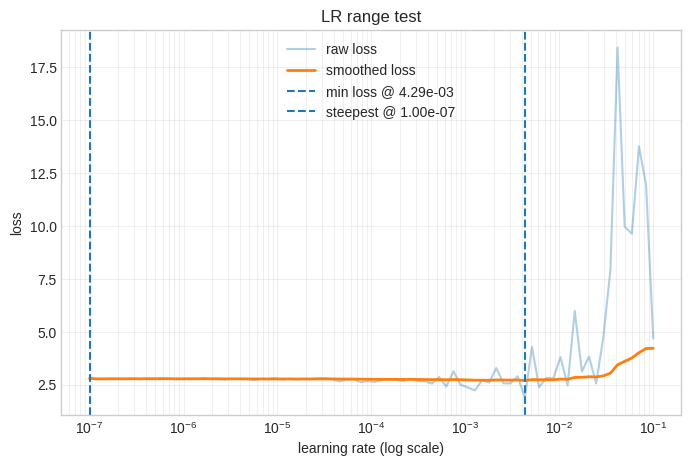

In [ ]:
# # Tune these per run
# LRF_NUM_BATCHES = 80
# LRF_START_LR = 1e-7
# LRF_END_LR = 1e-1

# lr_device = torch.device('cuda' if USE_CUDA else 'cpu')
# lr_history = run_lr_range_test(
#     model=model,
#     train_dataloader=trainer.get_train_dataloader(),
#     device=lr_device,
#     start_lr=LRF_START_LR,
#     end_lr=LRF_END_LR,
#     num_iter=LRF_NUM_BATCHES,
# )

# lrs = lr_history['lrs']
# raw_losses = lr_history['losses']
# smooth_losses = lr_history['smooth_losses']

# best_idx = int(np.argmin(smooth_losses))
# lr_at_min = float(lrs[best_idx])
# suggested_lr_min_rule = lr_at_min / 10.0

# log_lrs = np.log10(lrs)
# grad = np.gradient(smooth_losses, log_lrs)
# steep_idx = int(np.argmin(grad))
# lr_steep = float(lrs[steep_idx])

# print(f'LR at minimum smoothed loss: {lr_at_min:.3e}')
# print(f'Suggested LR (min-loss rule /10): {suggested_lr_min_rule:.3e}')
# print(f'Suggested LR (steepest descent): {lr_steep:.3e}')

# plt.figure(figsize=(8, 5))
# plt.plot(lrs, raw_losses, alpha=0.35, label='raw loss')
# plt.plot(lrs, smooth_losses, linewidth=2, label='smoothed loss')
# plt.axvline(lr_at_min, linestyle='--', label=f'min loss @ {lr_at_min:.2e}')
# plt.axvline(lr_steep, linestyle='--', label=f'steepest @ {lr_steep:.2e}')
# plt.xscale('log')
# plt.xlabel('learning rate (log scale)')
# plt.ylabel('loss')
# plt.title('LR range test')
# plt.legend()
# plt.grid(True, which='both', alpha=0.3)
# plt.show()


In [41]:
# Train
resume_ckpt = resolve_checkpoint_path(OUTPUT_DIR, RESUME_TRAIN_FROM_CHECKPOINT)
if resume_ckpt is not None:
    print(f'Resuming training from checkpoint: {resume_ckpt}')
    train_result = trainer.train(resume_from_checkpoint=str(resume_ckpt))
else:
    train_result = trainer.train()

comet_ml.end()
print(train_result.metrics)


COMET INFO: An experiment with the same configuration options is already running and will be reused.
/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(


Step,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
20,11.072168,2.762084,0.089928,0.032970,0.032171,0.053125
40,11.008179,2.729394,0.165468,0.035224,0.036400,0.073438
60,10.868164,2.676105,0.276978,0.110720,0.096971,0.160938
80,10.608130,2.600136,0.237410,0.102421,0.099000,0.143750
100,10.504834,2.537770,0.280576,0.111576,0.097137,0.162500
120,10.240564,2.466481,0.302158,0.115477,0.098541,0.171875
140,9.722168,2.460962,0.273381,0.117863,0.166245,0.160312
160,9.150159,2.303574,0.305755,0.122150,0.132662,0.174375
180,9.052979,2.188094,0.330935,0.136281,0.118233,0.190000
200,8.712915,2.298784,0.305755,0.135499,0.124786,0.179063


/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : wavlm_annotated_full_tuning
COMET INFO:     url                   : https://www.comet.com/13evgeniymarchuk89/general/4a0fa53016d24a5bb2c52f9bacfb0e31
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     eval/accuracy [165]            : (0.03597122302158273, 0.7697841726618705)
COMET INFO:     eval/f1_macro [165]            : (0.004340277777777778, 0.7597576758820916)
COMET INFO:     eval/loss [165]                : (0.8743030428886414, 2.776465892791748)
COMET INFO:     eval/precision_macro [165]     : (0.0022482014388489208, 0.7833453674262498)
COMET INFO:     eval/recall_macro [165]        : (0.053125000000000006, 0.7831009615384615)
COMET INF

{'train_runtime': 5192.6253, 'train_samples_per_second': 9.19, 'train_steps_per_second': 0.578, 'total_flos': 5.062369638025534e+18, 'train_loss': 3.2271149501800536, 'epoch': 20.0}


Loaded checkpoint for evaluation: /home/evgeniy/Projects/VocalAssistant/MainExperiments/outputs/wavlm_annotated_vocalset/wavlm_annotated_full_tuning/checkpoint-3000


/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(


COMET INFO: An experiment with the same configuration options is already running and will be reused.


NotebookProgressCallback issue detected; skipping trainer.evaluate and using predict-based metrics.
Validation metrics (trainer):
{
  "eval_skipped_due_to_callback_issue": true
}


/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(



Train classification metrics:
{
  "accuracy": 0.8922883487007544,
  "f1_macro": 0.8812366462840138,
  "precision_macro": 0.8882653100993061,
  "recall_macro": 0.8846934691790906
}

Validation classification metrics:
{
  "accuracy": 0.7446043165467626,
  "f1_macro": 0.7233448335071047,
  "precision_macro": 0.750130550550614,
  "recall_macro": 0.751454326923077
}

Train classification report:


,precision,recall,f1-score,support
Belt_Harsh,0.783410,1.000000,0.878553,170.000000
Breathy,0.916667,0.804878,0.857143,82.000000
Fast_Articulated_Forte,0.861486,0.855705,0.858586,298.000000
Fast_Articulated_Piano,0.995708,0.729560,0.842105,318.000000
FullVoice,0.954545,0.988235,0.971098,85.000000
Lip_Trill,0.993151,1.000000,0.996564,145.000000
MessaDiVoce,0.967391,1.000000,0.983425,89.000000
MoltoVibrato,0.748344,0.918699,0.824818,123.000000
Slow_Legato_Forte,0.706897,0.465909,0.561644,88.000000
Slow_Legato_Piano,0.918421,0.988669,0.952251,353.000000



Validation classification report:


,precision,recall,f1-score,support
Belt_Harsh,0.730769,0.950000,0.826087,20.000000
Breathy,1.000000,0.400000,0.571429,5.000000
Fast_Articulated_Forte,0.723404,0.850000,0.781609,40.000000
Fast_Articulated_Piano,0.884615,0.575000,0.696970,40.000000
FullVoice,0.714286,1.000000,0.833333,10.000000
Lip_Trill,0.823529,1.000000,0.903226,14.000000
MessaDiVoce,0.454545,1.000000,0.625000,10.000000
MoltoVibrato,0.565217,0.812500,0.666667,16.000000
Slow_Legato_Forte,0.375000,0.230769,0.285714,13.000000
Slow_Legato_Piano,0.935484,0.725000,0.816901,40.000000


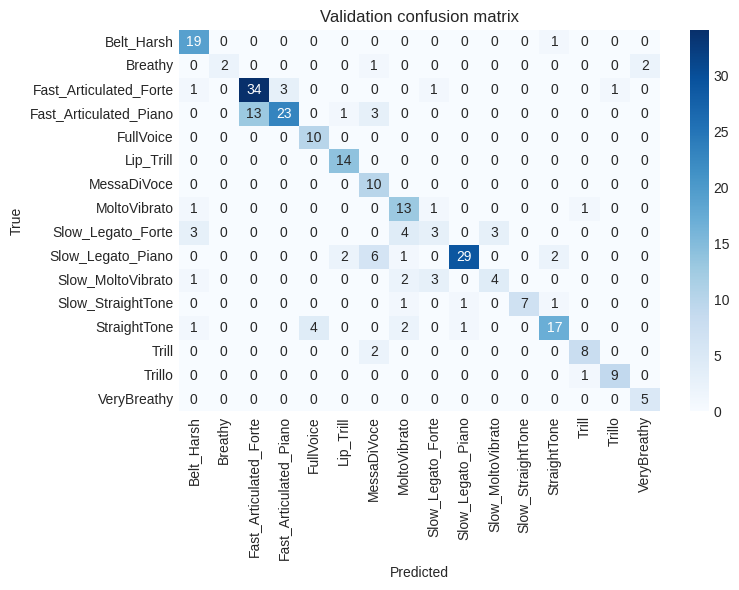

Saved to: /home/evgeniy/Projects/VocalAssistant/MainExperiments/outputs/wavlm_annotated_vocalset/wavlm_annotated_full_tuning


In [41]:
# If trainer crashed / kernel restarted, load checkpoint weights before evaluation.
# Options: None | 'latest' | 'checkpoint-3000' | '/abs/path/checkpoint-3000'
EVAL_CHECKPOINT = 'latest'
loaded_ckpt = load_checkpoint_into_trainer_for_eval(
    trainer=trainer,
    output_dir=OUTPUT_DIR,
    checkpoint=EVAL_CHECKPOINT,
)

# Validation metrics from trainer (kept for backward compatibility)
val_trainer_metrics = safe_trainer_evaluate(trainer, val_ds)
print('Validation metrics (trainer):')
print(json.dumps(val_trainer_metrics, indent=2, ensure_ascii=False))

# Detailed classification metrics on train and val splits
train_pred = trainer.predict(train_ds)
val_pred = trainer.predict(val_ds)

train_metrics, train_report_df, train_cm_df = build_split_artifacts(train_pred, id2label)
val_metrics, val_report_df, val_cm_df = build_split_artifacts(val_pred, id2label)

print('\nTrain classification metrics:')
print(json.dumps(train_metrics, indent=2, ensure_ascii=False))
print('\nValidation classification metrics:')
print(json.dumps(val_metrics, indent=2, ensure_ascii=False))

print('\nTrain classification report:')
display(train_report_df)
print('\nValidation classification report:')
display(val_report_df)

# Plot validation confusion matrix (as before)
plt.figure(figsize=(8, 6))
sns.heatmap(val_cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Validation confusion matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save per-split reports and confusion matrices
train_report_df.to_csv(OUTPUT_DIR / 'train_classification_report_full_tuning.csv')
train_cm_df.to_csv(OUTPUT_DIR / 'train_confusion_matrix_full_tuning.csv')

val_report_df.to_csv(OUTPUT_DIR / 'val_classification_report_full_tuning.csv')
val_cm_df.to_csv(OUTPUT_DIR / 'val_confusion_matrix_full_tuning.csv')

# Save aggregate metrics JSON
metrics_payload = {
    'train_metrics': train_metrics,
    'val_metrics': val_metrics,
    'val_trainer_metrics': val_trainer_metrics,
}
with open(OUTPUT_DIR / 'val_metrics_full_tuning.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_payload, f, indent=2, ensure_ascii=False)

print('Saved to:', OUTPUT_DIR)


/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(


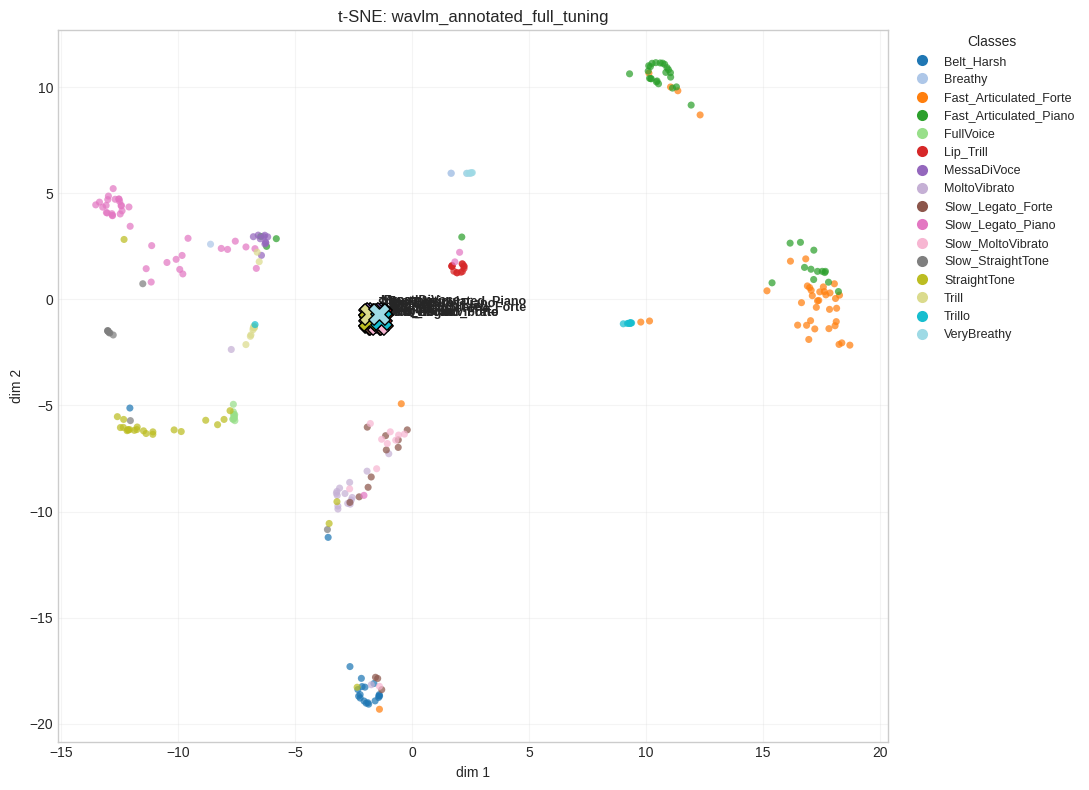

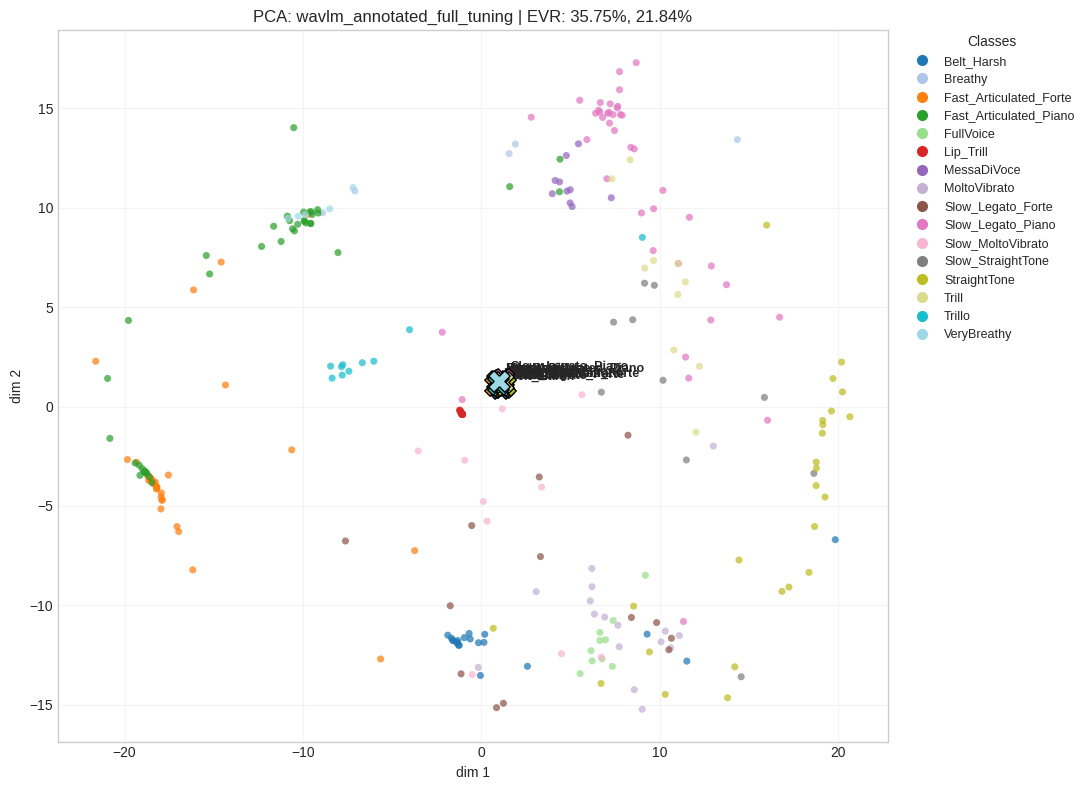

Saved t-SNE plot to: tsne_plots/tsne_wavlm_annotated_full_tuning.png
Saved PCA plot to: tsne_plots/pca_wavlm_annotated_full_tuning.png


In [42]:
# t-SNE visualization for current trained model
TSNE_PLOTS_DIR = Path('./tsne_plots')
TSNE_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

current_model = trainer.model
val_loader = trainer.get_eval_dataloader(val_ds)
run_name = OUTPUT_DIR.name

val_embeddings, val_labels, reference_vectors, class_names = extract_embeddings_and_references(
    model=current_model,
    dataloader=val_loader,
    processor=feature_extractor,
    device=DEVICE,
)

tsne_path = TSNE_PLOTS_DIR / f'tsne_{run_name}.png'
plot_tsne(
    embeddings=val_embeddings,
    labels=val_labels,
    references=reference_vectors,
    class_names=class_names,
    title=f't-SNE: {run_name}',
    save_path=tsne_path,
)

pca_path = TSNE_PLOTS_DIR / f'pca_{run_name}.png'
plot_pca(
    embeddings=val_embeddings,
    labels=val_labels,
    references=reference_vectors,
    class_names=class_names,
    title=f'PCA: {run_name}',
    save_path=pca_path,
)

print(f'Saved t-SNE plot to: {tsne_path}')
print(f'Saved PCA plot to: {pca_path}')


## Notes
- Для стабильности по умолчанию исключаются слишком редкие классы (`MIN_CLASS_SAMPLES=30`).
- Можно ограничить типы задач (например только `Scale`/`Arpeggio`) через `ALLOWED_MUSIC_TYPES`.
- Если хочется более сильного дообучения, попробуй второй прогон с `FREEZE_FEATURE_ENCODER=False`.


# Tuning Head

In [42]:
RUN_NAME = 'wavlm_annotated_head_tuning'
OUTPUT_DIR = get_output_dir_for_run(RUN_NAME)
print(f'Using RUN_NAME: {RUN_NAME}')
print(f'Saving checkpoints to: {OUTPUT_DIR}')

# For training resume use this in train cell:
# RESUME_TRAIN_FROM_CHECKPOINT = 'latest' or 'checkpoint-3000' or '/abs/path/checkpoint-3000'
RESUME_TRAIN_FROM_CHECKPOINT = None

trainer = Trainer(
    model=model,
    args=build_training_args(OUTPUT_DIR),
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=AudioCollator(
        feature_extractor=feature_extractor,
        max_length=max_length,
        target_sampling_rate=sampling_rate,
    ),
    compute_metrics=compute_metrics,
)

trainer


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(


LR at minimum smoothed loss: 4.294e-03
Suggested LR (min-loss rule /10): 4.294e-04
Suggested LR (steepest descent): 1.000e-07


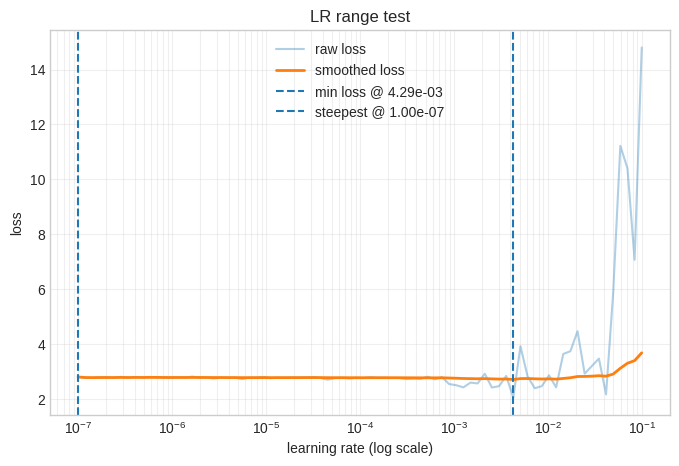

In [ ]:
# # Tune these per run
# LRF_NUM_BATCHES = 80
# LRF_START_LR = 1e-7
# LRF_END_LR = 1e-1

# lr_device = DEVICE
# lr_history = run_lr_range_test(
#     model=model,
#     train_dataloader=trainer.get_train_dataloader(),
#     device=lr_device,
#     start_lr=LRF_START_LR,
#     end_lr=LRF_END_LR,
#     num_iter=LRF_NUM_BATCHES,
# )

# lrs = lr_history['lrs']
# raw_losses = lr_history['losses']
# smooth_losses = lr_history['smooth_losses']

# best_idx = int(np.argmin(smooth_losses))
# lr_at_min = float(lrs[best_idx])
# suggested_lr_min_rule = lr_at_min / 10.0

# log_lrs = np.log10(lrs)
# grad = np.gradient(smooth_losses, log_lrs)
# steep_idx = int(np.argmin(grad))
# lr_steep = float(lrs[steep_idx])

# print(f'LR at minimum smoothed loss: {lr_at_min:.3e}')
# print(f'Suggested LR (min-loss rule /10): {suggested_lr_min_rule:.3e}')
# print(f'Suggested LR (steepest descent): {lr_steep:.3e}')

# plt.figure(figsize=(8, 5))
# plt.plot(lrs, raw_losses, alpha=0.35, label='raw loss')
# plt.plot(lrs, smooth_losses, linewidth=2, label='smoothed loss')
# plt.axvline(lr_at_min, linestyle='--', label=f'min loss @ {lr_at_min:.2e}')
# plt.axvline(lr_steep, linestyle='--', label=f'steepest @ {lr_steep:.2e}')
# plt.xscale('log')
# plt.xlabel('learning rate (log scale)')
# plt.ylabel('loss')
# plt.title('LR range test')
# plt.legend()
# plt.grid(True, which='both', alpha=0.3)
# plt.show()


In [ ]:
# Train
resume_ckpt = resolve_checkpoint_path(OUTPUT_DIR, RESUME_TRAIN_FROM_CHECKPOINT)
if resume_ckpt is not None:
    print(f'Resuming training from checkpoint: {resume_ckpt}')
    train_result = trainer.train(resume_from_checkpoint=str(resume_ckpt))
else:
    train_result = trainer.train()

comet_ml.end()
print(train_result.metrics)


COMET INFO: An experiment with the same configuration options is already running and will be reused.
/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(


Step,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
20,11.057715,2.751096,0.115108,0.039763,0.034027,0.062187
40,10.934912,2.696802,0.172662,0.041768,0.043961,0.078125
60,10.724780,2.633009,0.205036,0.041255,0.029195,0.089062
80,10.446448,2.569115,0.143885,0.015773,0.009025,0.062500
100,10.419910,2.518221,0.165468,0.029434,0.029389,0.071875
120,10.230200,2.470907,0.237410,0.082322,0.128105,0.116607
140,9.687317,2.404848,0.266187,0.095122,0.086497,0.141652
160,9.365039,2.353470,0.258993,0.093829,0.105593,0.143393
180,9.269580,2.282530,0.316547,0.142069,0.136167,0.188080
200,8.788702,2.200270,0.294964,0.116995,0.140644,0.172634


/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : WavLM | Freezed feature encoder
COMET INFO:     url                   : https://www.comet.com/13evgeniymarchuk89/general/0ec2813ba7a44b2b83a3ce70b4b77912
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     eval/accuracy [176]            : (0.11510791366906475, 0.5359712230215827)
COMET INFO:     eval/f1_macro [176]            : (0.015723270440251572, 0.44583321302141865)
COMET INFO:     eval/loss [176]                : (1.3009957075119019, 2.8930418491363525)
COMET INFO:     eval/precision_macro [176]     : (0.008992805755395683, 0.5480082266767049)
COMET INFO:     eval/recall_macro [176]        : (0.0621875, 0.47515624999999995)
COMET INFO:   

{'train_runtime': 3015.9635, 'train_samples_per_second': 15.822, 'train_steps_per_second': 0.995, 'total_flos': 5.062369638025534e+18, 'train_loss': 5.7119534428914385, 'epoch': 20.0}


/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(


COMET INFO: An experiment with the same configuration options is already running and will be reused.


NotebookProgressCallback issue detected; skipping trainer.evaluate and using predict-based metrics.
Validation metrics (trainer):
{
  "eval_skipped_due_to_callback_issue": true
}


/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(



Train classification metrics:
{
  "accuracy": 0.06160938809723386,
  "f1_macro": 0.027312547830393875,
  "precision_macro": 0.019622146314654993,
  "recall_macro": 0.05034416987223775
}

Validation classification metrics:
{
  "accuracy": 0.0683453237410072,
  "f1_macro": 0.026014803819305144,
  "precision_macro": 0.01937624007936508,
  "recall_macro": 0.045312500000000006
}

Train classification report:


,precision,recall,f1-score,support
Belt_Harsh,0.094937,0.176471,0.123457,170.000000
Breathy,0.000000,0.000000,0.000000,82.000000
Fast_Articulated_Forte,0.000000,0.000000,0.000000,298.000000
Fast_Articulated_Piano,0.102293,0.182390,0.131073,318.000000
FullVoice,0.047506,0.235294,0.079051,85.000000
Lip_Trill,0.000000,0.000000,0.000000,145.000000
MessaDiVoce,0.000000,0.000000,0.000000,89.000000
MoltoVibrato,0.000000,0.000000,0.000000,123.000000
Slow_Legato_Forte,0.000000,0.000000,0.000000,88.000000
Slow_Legato_Piano,0.000000,0.000000,0.000000,353.000000



Validation classification report:


,precision,recall,f1-score,support
Belt_Harsh,0.033333,0.050000,0.040000,20.000000
Breathy,0.000000,0.000000,0.000000,5.000000
Fast_Articulated_Forte,0.000000,0.000000,0.000000,40.000000
Fast_Articulated_Piano,0.174603,0.275000,0.213592,40.000000
FullVoice,0.050000,0.200000,0.080000,10.000000
Lip_Trill,0.000000,0.000000,0.000000,14.000000
MessaDiVoce,0.000000,0.000000,0.000000,10.000000
MoltoVibrato,0.000000,0.000000,0.000000,16.000000
Slow_Legato_Forte,0.000000,0.000000,0.000000,13.000000
Slow_Legato_Piano,0.000000,0.000000,0.000000,40.000000


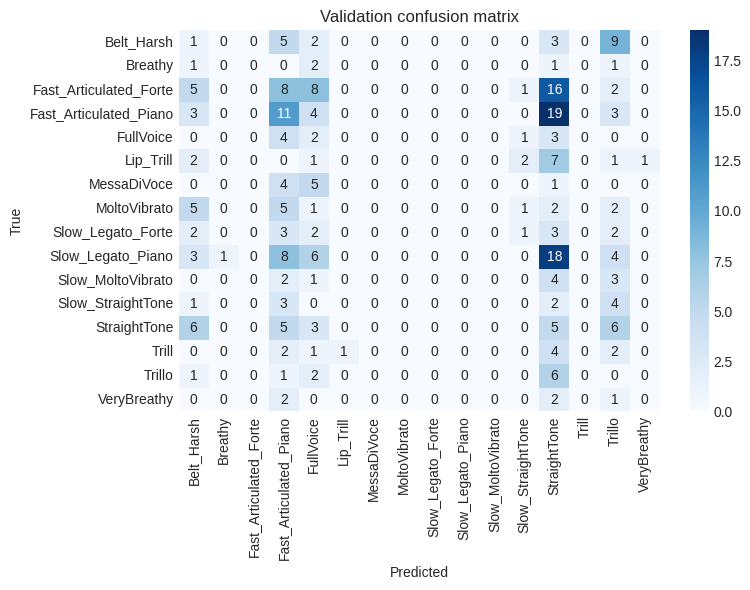

Saved to: /home/evgeniy/Projects/VocalAssistant/MainExperiments/outputs/wavlm_annotated_vocalset


In [43]:
# If trainer crashed / kernel restarted, load checkpoint weights before evaluation.
# Options: None | 'latest' | 'checkpoint-3000' | '/abs/path/checkpoint-3000'
EVAL_CHECKPOINT = 'latest'
loaded_ckpt = load_checkpoint_into_trainer_for_eval(
    trainer=trainer,
    output_dir=OUTPUT_DIR,
    checkpoint=EVAL_CHECKPOINT,
)

# Validation metrics from trainer (kept for backward compatibility)
val_trainer_metrics = safe_trainer_evaluate(trainer, val_ds)
print('Validation metrics (trainer):')
print(json.dumps(val_trainer_metrics, indent=2, ensure_ascii=False))

# Detailed classification metrics on train and val splits
train_pred = trainer.predict(train_ds)
val_pred = trainer.predict(val_ds)

train_metrics, train_report_df, train_cm_df = build_split_artifacts(train_pred, id2label)
val_metrics, val_report_df, val_cm_df = build_split_artifacts(val_pred, id2label)

print('\nTrain classification metrics:')
print(json.dumps(train_metrics, indent=2, ensure_ascii=False))
print('\nValidation classification metrics:')
print(json.dumps(val_metrics, indent=2, ensure_ascii=False))

print('\nTrain classification report:')
display(train_report_df)
print('\nValidation classification report:')
display(val_report_df)

# Plot validation confusion matrix (as before)
plt.figure(figsize=(8, 6))
sns.heatmap(val_cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Validation confusion matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save per-split reports and confusion matrices
train_report_df.to_csv(OUTPUT_DIR / 'train_classification_report_head_tuning.csv')
train_cm_df.to_csv(OUTPUT_DIR / 'train_confusion_matrix_head_tuning.csv')

val_report_df.to_csv(OUTPUT_DIR / 'val_classification_report_head_tuning.csv')
val_cm_df.to_csv(OUTPUT_DIR / 'val_confusion_matrix_head_tuning.csv')

# Save aggregate metrics JSON
metrics_payload = {
    'train_metrics': train_metrics,
    'val_metrics': val_metrics,
    'val_trainer_metrics': val_trainer_metrics,
}
with open(OUTPUT_DIR / 'val_metrics_head_tuning.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_payload, f, indent=2, ensure_ascii=False)

print('Saved to:', OUTPUT_DIR)


/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(


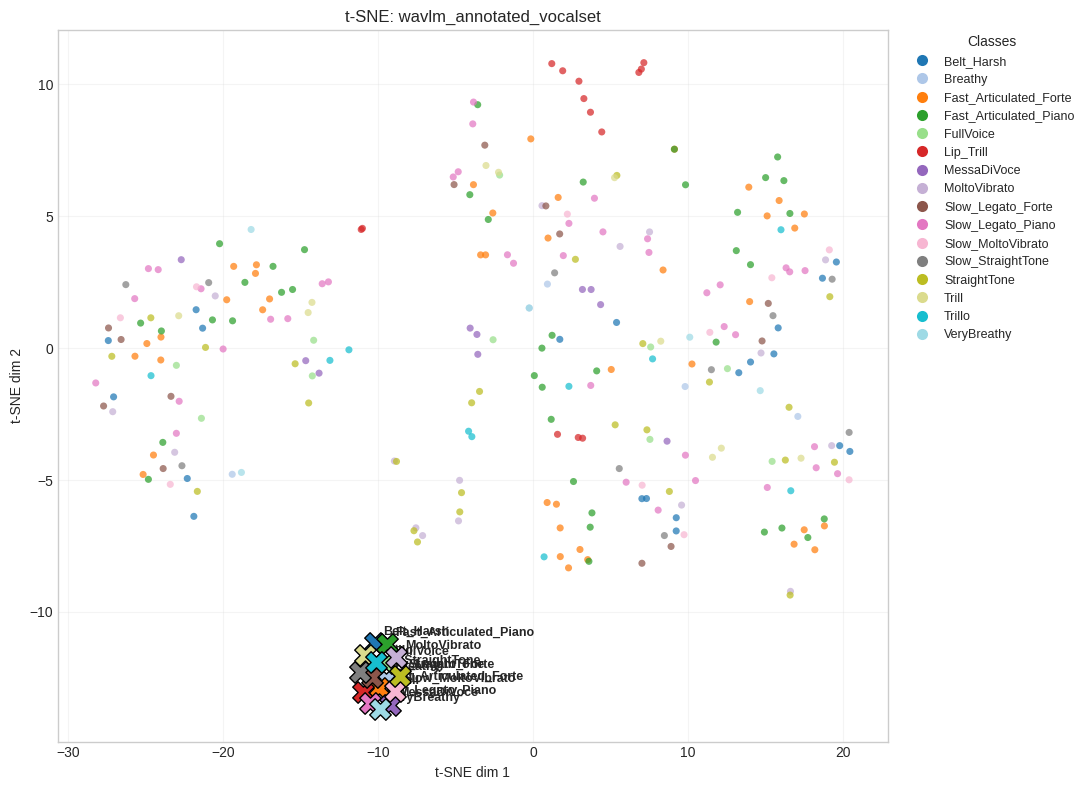

Saved t-SNE plot to: tsne_plots/tsne_wavlm_annotated_vocalset.png


In [41]:
# t-SNE visualization for current trained model
TSNE_PLOTS_DIR = Path('./tsne_plots')
TSNE_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

current_model = trainer.model
val_loader = trainer.get_eval_dataloader(val_ds)
run_name = OUTPUT_DIR.name

val_embeddings, val_labels, reference_vectors, class_names = extract_embeddings_and_references(
    model=current_model,
    dataloader=val_loader,
    processor=feature_extractor,
    device=DEVICE,
)

tsne_path = TSNE_PLOTS_DIR / f'tsne_{run_name}.png'
plot_tsne(
    embeddings=val_embeddings,
    labels=val_labels,
    references=reference_vectors,
    class_names=class_names,
    title=f't-SNE: {run_name}',
    save_path=tsne_path,
)

pca_path = TSNE_PLOTS_DIR / f'pca_{run_name}.png'
plot_pca(
    embeddings=val_embeddings,
    labels=val_labels,
    references=reference_vectors,
    class_names=class_names,
    title=f'PCA: {run_name}',
    save_path=pca_path,
)

print(f'Saved t-SNE plot to: {tsne_path}')
print(f'Saved PCA plot to: {pca_path}')


# LoRA tuning

In [31]:
from peft import LoraConfig, TaskType, get_peft_model

target_modules = ["projection", "k_proj", "v_proj", "q_proj", "out_proj", "dense"]
modules_to_save = ["projector", "classifier"]

peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    inference_mode=False,
    r=8,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=target_modules,
    modules_to_save=modules_to_save
)


In [32]:
peft_model = get_peft_model(model, peft_config)
peft_model.print_trainable_parameters()


trainable params: 801,040 || all params: 95,383,952 || trainable%: 0.8398


In [33]:
from torchinfo import summary

summary(peft_model, col_names=["num_params", "trainable"])


Layer (type:depth-idx)                                                 Param #                   Trainable
PeftModelForSequenceClassification                                     --                        Partial
├─LoraModel: 1-1                                                       --                        Partial
│    └─WavLMForSequenceClassification: 2-1                             --                        Partial
│    │    └─WavLMModel: 3-1                                            94,982,000                Partial
│    │    └─ModulesToSaveWrapper: 3-2                                  393,728                   Partial
│    │    └─ModulesToSaveWrapper: 3-3                                  8,224                     Partial
Total params: 95,383,952
Trainable params: 801,040
Non-trainable params: 94,582,912

In [34]:
RUN_NAME = 'wavlm_annotated_lora_tuning'
OUTPUT_DIR = get_output_dir_for_run(RUN_NAME)
print(f'Using RUN_NAME: {RUN_NAME}')
print(f'Saving checkpoints to: {OUTPUT_DIR}')

# For training resume use this in train cell:
# RESUME_TRAIN_FROM_CHECKPOINT = 'latest' or 'checkpoint-3000' or '/abs/path/checkpoint-3000'
RESUME_TRAIN_FROM_CHECKPOINT = None

trainer = Trainer(
    model=peft_model,
    args=build_training_args(OUTPUT_DIR),
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=AudioCollator(
        feature_extractor=feature_extractor,
        max_length=max_length,
        target_sampling_rate=sampling_rate,
    ),
    compute_metrics=compute_metrics,
)

trainer


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Using RUN_NAME: wavlm_annotated_lora_tuning
Saving checkpoints to: /home/evgeniy/Projects/VocalAssistant/MainExperiments/outputs/wavlm_annotated_vocalset/wavlm_annotated_lora_tuning


In [35]:
# # Tune these per run
# LRF_NUM_BATCHES = 80
# LRF_START_LR = 1e-7
# LRF_END_LR = 1e-1

# lr_device = DEVICE
# lr_history = run_lr_range_test(
#     model=peft_model,
#     train_dataloader=trainer.get_train_dataloader(),
#     device=lr_device,
#     start_lr=LRF_START_LR,
#     end_lr=LRF_END_LR,
#     num_iter=LRF_NUM_BATCHES,
# )

# lrs = lr_history['lrs']
# raw_losses = lr_history['losses']
# smooth_losses = lr_history['smooth_losses']

# best_idx = int(np.argmin(smooth_losses))
# lr_at_min = float(lrs[best_idx])
# suggested_lr_min_rule = lr_at_min / 10.0

# log_lrs = np.log10(lrs)
# grad = np.gradient(smooth_losses, log_lrs)
# steep_idx = int(np.argmin(grad))
# lr_steep = float(lrs[steep_idx])

# print(f'LR at minimum smoothed loss: {lr_at_min:.3e}')
# print(f'Suggested LR (min-loss rule /10): {suggested_lr_min_rule:.3e}')
# print(f'Suggested LR (steepest descent): {lr_steep:.3e}')

# plt.figure(figsize=(8, 5))
# plt.plot(lrs, raw_losses, alpha=0.35, label='raw loss')
# plt.plot(lrs, smooth_losses, linewidth=2, label='smoothed loss')
# plt.axvline(lr_at_min, linestyle='--', label=f'min loss @ {lr_at_min:.2e}')
# plt.axvline(lr_steep, linestyle='--', label=f'steepest @ {lr_steep:.2e}')
# plt.xscale('log')
# plt.xlabel('learning rate (log scale)')
# plt.ylabel('loss')
# plt.title('LR range test')
# plt.legend()
# plt.grid(True, which='both', alpha=0.3)
# plt.show()


In [36]:
# Train
resume_ckpt = resolve_checkpoint_path(OUTPUT_DIR, RESUME_TRAIN_FROM_CHECKPOINT)
if resume_ckpt is not None:
    print(f'Resuming training from checkpoint: {resume_ckpt}')
    train_result = trainer.train(resume_from_checkpoint=str(resume_ckpt))
else:
    train_result = trainer.train()

comet_ml.end()
print(train_result.metrics)


COMET INFO: An experiment with the same configuration options is already running and will be reused.
COMET WARNING: String value length exceeds 1000 characters and will be truncated. Provided value: 'LoraConfig(task_type=<TaskType.SEQ_CLS: 'SEQ_CLS'>, peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.19.1', base_model_name_or_path='microsoft/wavlm-base', revision=None, inference_mode=False, r=8, target_modules={'v_proj', 'out_proj', 'q_proj', 'dense', 'projection', 'k_proj'}, exclude_modules=None, lora_alpha=32, lora_dropout=0.1, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=['projector', 'classifier', 'classifier', 'score'], init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, lora_ga_config=None, use_dora=False, alora_invocation_tokens=None, use_qalora=Fal

Step,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
20,11.047485,2.743410,0.140288,0.047168,0.035958,0.073125
40,10.880396,2.668896,0.179856,0.044123,0.048808,0.081250
60,10.603394,2.589391,0.194245,0.039655,0.031890,0.084375
80,10.279126,2.529873,0.143885,0.015773,0.009025,0.062500
100,10.305701,2.460737,0.255396,0.087197,0.098076,0.128348
120,9.986389,2.364760,0.287770,0.113639,0.111625,0.155804
140,9.019891,2.211452,0.309353,0.132730,0.144688,0.180536
160,8.510383,2.184053,0.341727,0.171606,0.192951,0.203125
180,8.126075,2.171136,0.348921,0.178193,0.169779,0.218125
200,7.542090,2.108954,0.341727,0.162770,0.201490,0.211875


/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  

{'train_runtime': 5135.3571, 'train_samples_per_second': 9.292, 'train_steps_per_second': 0.584, 'total_flos': 5.105245514147937e+18, 'train_loss': 4.09743546295166, 'epoch': 20.0}


Loaded checkpoint for evaluation: /home/evgeniy/Projects/VocalAssistant/MainExperiments/outputs/wavlm_annotated_vocalset/wavlm_annotated_lora_tuning/checkpoint-3000


/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(


NotebookProgressCallback issue detected; skipping trainer.evaluate and using predict-based metrics.
Validation metrics (trainer):
{
  "eval_skipped_due_to_callback_issue": true
}


/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(
/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(



Train classification metrics:
{
  "accuracy": 0.5875943000838223,
  "f1_macro": 0.5369595434367294,
  "precision_macro": 0.5996090537662413,
  "recall_macro": 0.5500953503499594
}

Validation classification metrics:
{
  "accuracy": 0.6438848920863309,
  "f1_macro": 0.5755566320016212,
  "precision_macro": 0.5934124101887259,
  "recall_macro": 0.6002712912087913
}

Train classification report:


,precision,recall,f1-score,support
Belt_Harsh,0.522436,0.958824,0.676349,170.000000
Breathy,0.625000,0.243902,0.350877,82.000000
Fast_Articulated_Forte,0.784038,0.560403,0.653620,298.000000
Fast_Articulated_Piano,0.891473,0.361635,0.514541,318.000000
FullVoice,0.525000,0.494118,0.509091,85.000000
Lip_Trill,1.000000,0.910345,0.953069,145.000000
MessaDiVoce,0.594203,0.921348,0.722467,89.000000
MoltoVibrato,0.666667,0.390244,0.492308,123.000000
Slow_Legato_Forte,0.409836,0.284091,0.335570,88.000000
Slow_Legato_Piano,0.645833,0.702550,0.672999,353.000000



Validation classification report:


,precision,recall,f1-score,support
Belt_Harsh,0.629630,0.850000,0.723404,20.000000
Breathy,0.000000,0.000000,0.000000,5.000000
Fast_Articulated_Forte,0.736842,0.700000,0.717949,40.000000
Fast_Articulated_Piano,0.909091,0.500000,0.645161,40.000000
FullVoice,0.500000,0.900000,0.642857,10.000000
Lip_Trill,1.000000,0.928571,0.962963,14.000000
MessaDiVoce,0.454545,1.000000,0.625000,10.000000
MoltoVibrato,0.666667,0.625000,0.645161,16.000000
Slow_Legato_Forte,0.333333,0.230769,0.272727,13.000000
Slow_Legato_Piano,0.810811,0.750000,0.779221,40.000000


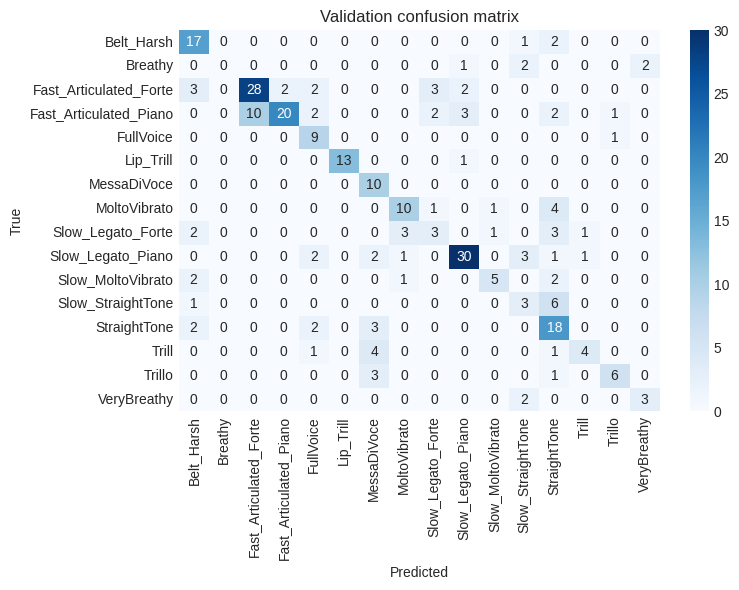

Saved to: /home/evgeniy/Projects/VocalAssistant/MainExperiments/outputs/wavlm_annotated_vocalset/wavlm_annotated_lora_tuning


In [37]:
# If trainer crashed / kernel restarted, load checkpoint weights before evaluation.
# Options: None | 'latest' | 'checkpoint-3000' | '/abs/path/checkpoint-3000'
EVAL_CHECKPOINT = 'latest'
loaded_ckpt = load_checkpoint_into_trainer_for_eval(
    trainer=trainer,
    output_dir=OUTPUT_DIR,
    checkpoint=EVAL_CHECKPOINT,
)

# Validation metrics from trainer (kept for backward compatibility)
val_trainer_metrics = safe_trainer_evaluate(trainer, val_ds)
print('Validation metrics (trainer):')
print(json.dumps(val_trainer_metrics, indent=2, ensure_ascii=False))

# Detailed classification metrics on train and val splits
train_pred = trainer.predict(train_ds)
val_pred = trainer.predict(val_ds)

train_metrics, train_report_df, train_cm_df = build_split_artifacts(train_pred, id2label)
val_metrics, val_report_df, val_cm_df = build_split_artifacts(val_pred, id2label)

print('\nTrain classification metrics:')
print(json.dumps(train_metrics, indent=2, ensure_ascii=False))
print('\nValidation classification metrics:')
print(json.dumps(val_metrics, indent=2, ensure_ascii=False))

print('\nTrain classification report:')
display(train_report_df)
print('\nValidation classification report:')
display(val_report_df)

# Plot validation confusion matrix (as before)
plt.figure(figsize=(8, 6))
sns.heatmap(val_cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Validation confusion matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save per-split reports and confusion matrices
train_report_df.to_csv(OUTPUT_DIR / 'train_classification_report_lora.csv')
train_cm_df.to_csv(OUTPUT_DIR / 'train_confusion_matrix_lora.csv')

val_report_df.to_csv(OUTPUT_DIR / 'val_classification_report_lora.csv')
val_cm_df.to_csv(OUTPUT_DIR / 'val_confusion_matrix_lora.csv')

# Save aggregate metrics JSON
metrics_payload = {
    'train_metrics': train_metrics,
    'val_metrics': val_metrics,
    'val_trainer_metrics': val_trainer_metrics,
}
with open(OUTPUT_DIR / 'val_metrics_lora.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_payload, f, indent=2, ensure_ascii=False)

print('Saved to:', OUTPUT_DIR)


/home/evgeniy/miniconda3/envs/vocal_assist_py310/lib/python3.10/site-packages/torch/nn/functional.py:6409: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(


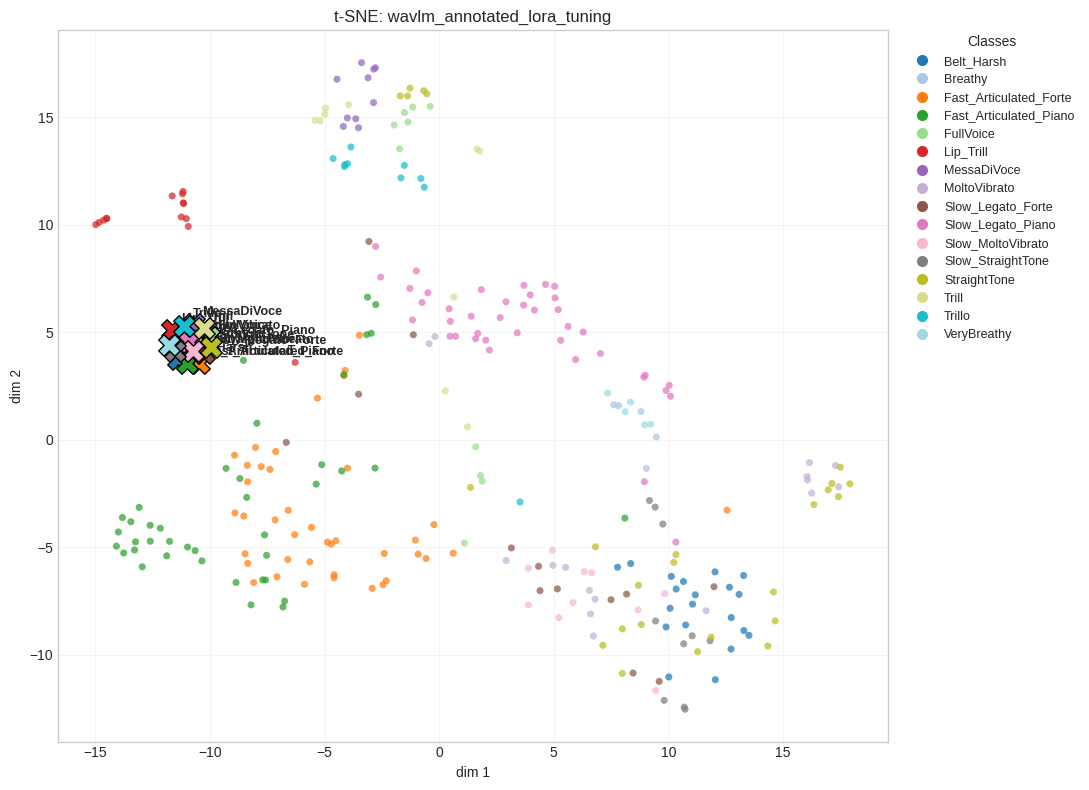

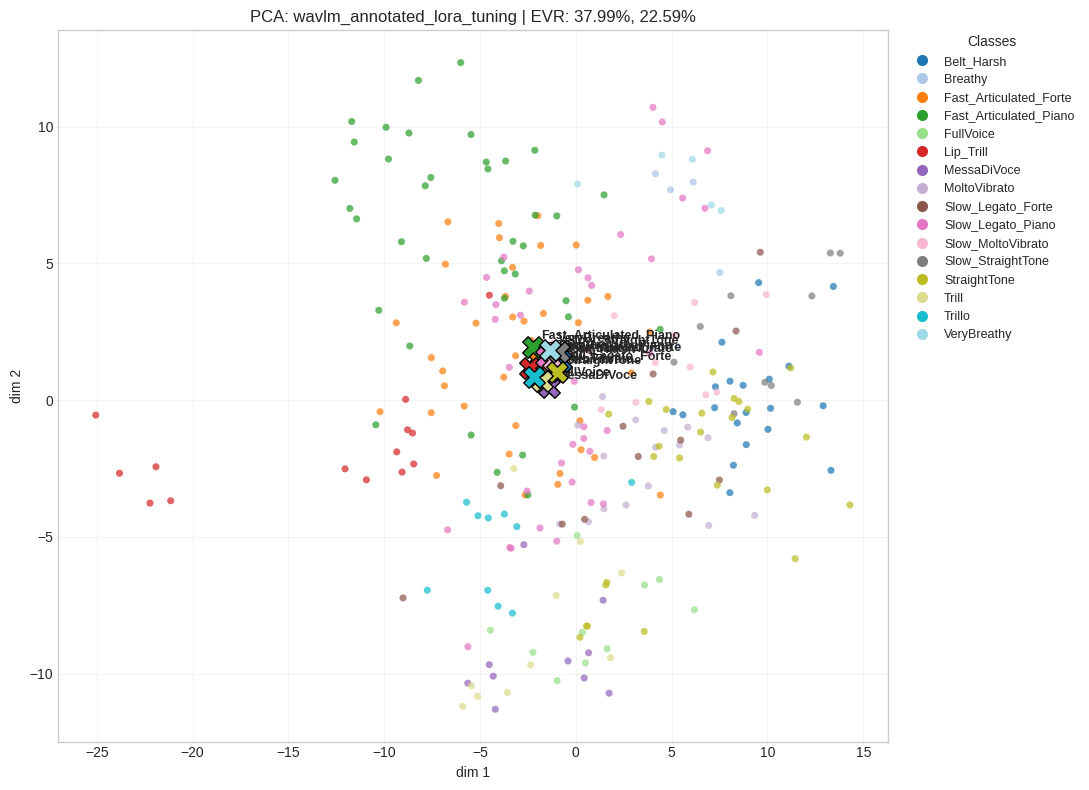

Saved t-SNE plot to: tsne_plots/tsne_wavlm_annotated_lora_tuning.png
Saved PCA plot to: tsne_plots/pca_wavlm_annotated_lora_tuning.png


In [38]:
# t-SNE visualization for current trained model
TSNE_PLOTS_DIR = Path('./tsne_plots')
TSNE_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

current_model = trainer.model
val_loader = trainer.get_eval_dataloader(val_ds)
run_name = OUTPUT_DIR.name

val_embeddings, val_labels, reference_vectors, class_names = extract_embeddings_and_references(
    model=current_model,
    dataloader=val_loader,
    processor=feature_extractor,
    device=DEVICE,
)

tsne_path = TSNE_PLOTS_DIR / f'tsne_{run_name}.png'
plot_tsne(
    embeddings=val_embeddings,
    labels=val_labels,
    references=reference_vectors,
    class_names=class_names,
    title=f't-SNE: {run_name}',
    save_path=tsne_path,
)

pca_path = TSNE_PLOTS_DIR / f'pca_{run_name}.png'
plot_pca(
    embeddings=val_embeddings,
    labels=val_labels,
    references=reference_vectors,
    class_names=class_names,
    title=f'PCA: {run_name}',
    save_path=pca_path,
)

print(f'Saved t-SNE plot to: {tsne_path}')
print(f'Saved PCA plot to: {pca_path}')
